In [56]:
import os

In [57]:
label_dict={0:'肿瘤',1:'肿瘤和间质',2:'间质',3:'正常'}

In [58]:
DIRECTORY='D:\\doctorUnet\\data\\result\\[1,0,0]'
f = open('D:\\doctorUnet\\data\\result\\[1,0,0]\\[1,0,0].txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '0')
    f.write('\n')
f.close()

In [59]:
DIRECTORY='D:\\doctorUnet\\data\\result\\[1,1,0]'
f = open('D:\\doctorUnet\\data\\result\\[1,1,0]\\[1,1,0].txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '1')
    f.write('\n')
f.close()

In [60]:
DIRECTORY='D:\\doctorUnet\\data\\result\\[0,1,0]'
f = open('D:\\doctorUnet\\data\\result\\[0,1,0]\\[0,1,0].txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '2')
    f.write('\n')
f.close()

In [61]:
DIRECTORY='D:\\doctorUnet\\data\\result\\[0,0,1]'
f = open('D:\\doctorUnet\\data\\result\\[0,0,1]\\[0,0,1].txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '3')
    f.write('\n')
f.close()

In [62]:
import random

In [82]:
DIRECTORY='D:\\doctorUnet\\data\\result\\all'
f = open('D:\\doctorUnet\\data\\result\\all\\train.txt','r')
list=[]
for i in range(0,5246):
    list.append(i)
random.shuffle(list)

num=[]

imgs=[]
line=f.readline()

while line:
    a = line.split('--')
    data = a[0]
    imgs.append(data)
    
    label = a[1][0]
    num.append(label)
    line = f.readline()

f.close()

In [83]:
import cv2

In [85]:
batch=[]
labels=[]
for j in range(len(list)):
    num_1=list[j]
    file_path=DIRECTORY+"\\"+imgs[num_1]
    img=cv2.imread(file_path)
    img=cv2.resize(img,(256,256),interpolation=cv2.INTER_CUBIC)
    batch.append(img)
    labels.append(num[num_1])

In [88]:
import numpy as np

In [89]:
x_train = np.array(batch)  

In [90]:
x_train.shape

(5246, 256, 256, 3)

In [91]:
x_train.dtype

dtype('uint8')

In [92]:
y_train=np.array(labels)

In [93]:
y_train.shape

(5246,)

In [96]:
from matplotlib import pyplot as plt

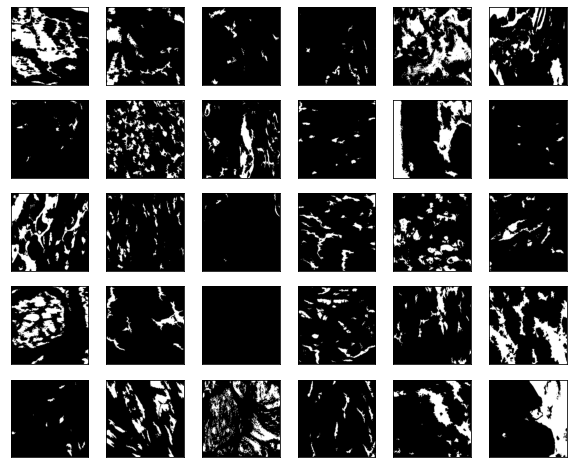

In [97]:
plt.figure(figsize=(10,10))
for i in range(30):
    plt.subplot(6,6,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

In [98]:
y_train.astype(np.float32)

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)

In [99]:
x_train=x_train.astype('float32')/255.0

In [100]:
import tensorflow as tf
from tensorflow import keras

In [101]:
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(filters=32,
                                kernel_size=(3,3),
                                input_shape=(256,256,3),
                                activation='relu',
                                padding='same'))
#第一个池化层
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=64,
                                kernel_size=(3,3),
                                activation='relu',
                                padding='same'))
#第二个池化层
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=128,
                                kernel_size=(3,3),
                                activation='relu',
                                padding='same'))
#第三个池化层
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=256,
                                kernel_size=(3,3),
                                activation='relu',
                                padding='same'))
#第四个池化层
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

#128全连接层
model.add(tf.keras.layers.Dense(512,activation='relu'))

#平坦层
model.add(tf.keras.layers.Flatten())
#添加输出层
model.add(tf.keras.layers.Dense(10,activation='softmax'))

In [102]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 256, 256, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 128, 128, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 128, 128, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 64, 64, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 32, 32, 128)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 32, 32, 256)       2

In [103]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [104]:
x_train=x_train.astype(np.uint8)

In [105]:
y_train=y_train.astype(np.uint8)

In [106]:
x_test=x_test.astype(np.uint8)
y_test=y_test.astype(np.uint8)

In [107]:
train_history=model.fit(x_train,y_train,
                        validation_split=0.2,
                       epochs=20,
                       batch_size=5,
                       verbose=2)

Epoch 1/20
840/840 - 168s - loss: 1.2402 - accuracy: 0.4135 - val_loss: 1.1524 - val_accuracy: 0.4648
Epoch 2/20
840/840 - 168s - loss: 1.1620 - accuracy: 0.4716 - val_loss: 1.1134 - val_accuracy: 0.4829
Epoch 3/20
840/840 - 168s - loss: 1.0948 - accuracy: 0.5274 - val_loss: 1.1150 - val_accuracy: 0.4848
Epoch 4/20
840/840 - 2900s - loss: 0.9630 - accuracy: 0.5982 - val_loss: 1.2674 - val_accuracy: 0.4267
Epoch 5/20
840/840 - 190s - loss: 0.7163 - accuracy: 0.7247 - val_loss: 1.4317 - val_accuracy: 0.4371
Epoch 6/20
840/840 - 189s - loss: 0.3706 - accuracy: 0.8668 - val_loss: 2.0730 - val_accuracy: 0.4057
Epoch 7/20
840/840 - 187s - loss: 0.1755 - accuracy: 0.9423 - val_loss: 3.5985 - val_accuracy: 0.3752
Epoch 8/20
840/840 - 185s - loss: 0.1560 - accuracy: 0.9507 - val_loss: 3.2077 - val_accuracy: 0.4038
Epoch 9/20
840/840 - 194s - loss: 0.1186 - accuracy: 0.9647 - val_loss: 4.4064 - val_accuracy: 0.4133
Epoch 10/20
840/840 - 205s - loss: 0.1188 - accuracy: 0.9659 - val_loss: 3.9950 -

In [108]:
DIRECTORY='D:\\taitan\\data\\test\\[1,0,0]'
f = open('D:\\taitan\\data\\test\\[1,0,0]\\test0.txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '0')
    f.write('\n')
f.close()
DIRECTORY='D:\\taitan\\data\\test\\[1,1,0]'
f = open('D:\\taitan\\data\\test\\[1,1,0]\\test1.txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '1')
    f.write('\n')
f.close()

In [109]:
DIRECTORY='D:\\taitan\\data\\test\\[0,0,1]'
f = open('D:\\taitan\\data\\test\\[0,0,1]\\test3.txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '3')
    f.write('\n')
f.close()
DIRECTORY='D:\\taitan\\data\\test\\[0,1,0]'
f = open('D:\\taitan\\data\\test\\[0,1,0]\\test2.txt','w')

files=os.listdir(DIRECTORY)
for file in files:
    f.writelines(file+ '--' + '2')
    f.write('\n')
f.close()

In [114]:
DIRECTORY='D:\\taitan\\data\\test\\all'
f=open('D:\\taitan\\data\\test\\all\\test.txt','r')
list=[]
for i in range(0,200):
    list.append(i)
random.shuffle(list)

num=[]

imgs=[]
line=f.readline()

while line:
    a = line.split('--')
    data = a[0]
    imgs.append(data)
    label = a[1][0]
    num.append(label)
    line = f.readline()
f.close()


In [115]:
imgs[0]

'3 (220).png'

In [116]:
num[0]

'3'

In [121]:
batch_test=[]
labels_test=[]
for j in range(len(list)):
    num_1=list[j]
    file_path=DIRECTORY+"\\"+imgs[num_1]
    img=cv2.imread(file_path)
    img=cv2.resize(img,(256,256),interpolation=cv2.INTER_CUBIC)
    batch_test.append(img)
    labels_test.append(num[num_1])

In [134]:
x_test=np.array(batch_test)
y_test=np.array(labels_test)
y_test=y_test.astype(np.float32)
x_test=x_test.astype('float32')/255.0

In [135]:
x_test.shape

(200, 256, 256, 3)

In [136]:
y_test.shape

(200,)

In [137]:
x_test.dtype

dtype('float32')

In [138]:
y_test.dtype

dtype('float32')

In [142]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print('accuracy ',test_acc)

7/7 - 2s - loss: 0.6615 - accuracy: 0.8200
accuracy  0.8199999928474426


In [140]:
preds=model.predict_classes(x_test)
preds

array([2, 3, 2, 1, 2, 0, 3, 2, 3, 1, 1, 3, 2, 3, 3, 1, 3, 1, 0, 0, 3, 0,
       0, 0, 3, 2, 0, 2, 0, 0, 0, 2, 2, 0, 3, 2, 2, 1, 2, 3, 2, 0, 0, 1,
       0, 0, 2, 3, 1, 1, 1, 1, 0, 1, 1, 3, 2, 0, 3, 2, 0, 0, 1, 3, 0, 0,
       2, 3, 1, 3, 3, 2, 1, 0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 1, 3,
       2, 2, 3, 0, 2, 0, 1, 1, 1, 2, 3, 1, 3, 3, 1, 1, 2, 1, 3, 0, 0, 2,
       3, 1, 2, 2, 2, 2, 3, 0, 2, 1, 3, 2, 3, 0, 2, 2, 1, 0, 2, 0, 3, 0,
       0, 3, 0, 1, 3, 3, 3, 1, 1, 3, 2, 2, 0, 0, 2, 3, 2, 3, 3, 0, 0, 2,
       1, 0, 2, 2, 3, 1, 3, 2, 3, 3, 2, 0, 0, 2, 0, 3, 0, 2, 1, 3, 1, 3,
       3, 3, 0, 3, 0, 3, 1, 1, 3, 1, 2, 1, 0, 1, 0, 2, 3, 2, 1, 2, 2, 0,
       1, 1], dtype=int64)

In [141]:
y_test

array([2., 2., 0., 1., 2., 0., 3., 1., 3., 1., 1., 3., 2., 3., 3., 1., 3.,
       1., 3., 0., 3., 0., 1., 0., 3., 2., 0., 2., 0., 0., 0., 2., 0., 0.,
       2., 2., 2., 0., 2., 3., 2., 0., 0., 1., 0., 0., 2., 1., 1., 1., 1.,
       1., 0., 1., 1., 3., 2., 0., 3., 2., 2., 0., 2., 3., 0., 0., 2., 3.,
       1., 3., 3., 2., 1., 0., 1., 1., 1., 2., 2., 0., 0., 0., 0., 1., 1.,
       1., 1., 3., 2., 2., 3., 0., 2., 0., 0., 1., 1., 2., 3., 1., 3., 3.,
       1., 1., 1., 1., 3., 2., 0., 2., 3., 1., 2., 1., 2., 2., 3., 0., 2.,
       0., 3., 2., 3., 0., 2., 2., 1., 0., 1., 0., 3., 2., 0., 3., 2., 1.,
       3., 3., 3., 1., 1., 3., 2., 2., 0., 0., 2., 3., 0., 3., 3., 0., 0.,
       2., 3., 0., 2., 2., 3., 3., 3., 2., 3., 3., 1., 0., 2., 2., 0., 1.,
       0., 2., 0., 3., 1., 3., 3., 0., 1., 3., 0., 3., 1., 1., 3., 1., 1.,
       1., 0., 2., 0., 1., 3., 2., 1., 2., 2., 3., 3., 1.], dtype=float32)